<div style="text-align: center;">

# Deep Learning Models for Promoter Prediction  
## Evaluating CNNs and Transformers on Genomic Sequences  

### Exploratory Data Analysis  

<br>

**Radek Holik**  

April 2026  

</div>

---

### Description
This notebook explores genomic and promoter sequence data, including sequence characteristics, base composition, and data quality. The goal is to understand the structure of the data before preprocessing and model development.

---

### Imports and paths

In [19]:
from pathlib import Path
import os
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [2]:
# Paths
project_root = Path("..").resolve()
data_dir = project_root / "data"
raw_dir = data_dir / "raw"
genome_dir = raw_dir / "genome"
uci_dir = raw_dir / "uci_promoter"

fa_path = genome_dir / "chr1.fa"

def rel(path):
    return Path(os.path.relpath(path, project_root))

print("Project root:")
print("Genome file:", rel(fa_path).as_posix())
print("UCI folder:", rel(uci_dir).as_posix())

Project root:
Genome file: data/raw/genome/chr1.fa
UCI folder: data/raw/uci_promoter


### Load FASTA File

In [3]:
def read_fasta(file_path):
    with open(file_path, "r") as f:
        header = f.readline().strip()
        sequence = "".join(line.strip() for line in f)
    return header, sequence

header, sequence = read_fasta(fa_path)

print("Genome loaded.")
print("Header:")
print(header)
print()
print(f"Total sequence length: {len(sequence):,} bases")

Genome loaded.
Header:
>1 dna:chromosome chromosome:GRCh38:1:1:248956422:1 REF

Total sequence length: 248,956,422 bases


### Basic Genome Quality Checks

In [4]:
first_real_idx = next((i for i, base in enumerate(sequence) if base in {"A", "C", "G", "T"}), None)
usable_sequence = sequence[first_real_idx:]

print(f"First real DNA base position: {first_real_idx:,}")
print()
print("First 100 bases of raw sequence:")
print(sequence[:100])
print()
print("First 100 real DNA bases:")
print(sequence[first_real_idx:first_real_idx + 100])
print()
print(f"Usable sequence length: {len(usable_sequence):,}")

First real DNA base position: 10,000

First 100 bases of raw sequence:
NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN

First 100 real DNA bases:
TAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAACCCTAAC

Usable sequence length: 248,946,422


### Count and Percentage Calculations

In [5]:
usable_base_counts = Counter(usable_sequence)

usable_length = len(usable_sequence)

print("Usable base counts and percentages:")
for base in ["A", "C", "G", "T", "N"]:
    count = usable_base_counts.get(base, 0)
    pct = (count / usable_length) * 100
    print(f"{base}: {count:,} ({pct:.2f}%)")

Usable base counts and percentages:
A: 67,070,277 (26.94%)
C: 48,055,043 (19.30%)
G: 48,111,528 (19.33%)
T: 67,244,164 (27.01%)
N: 18,465,410 (7.42%)


### Visualize Base Composition

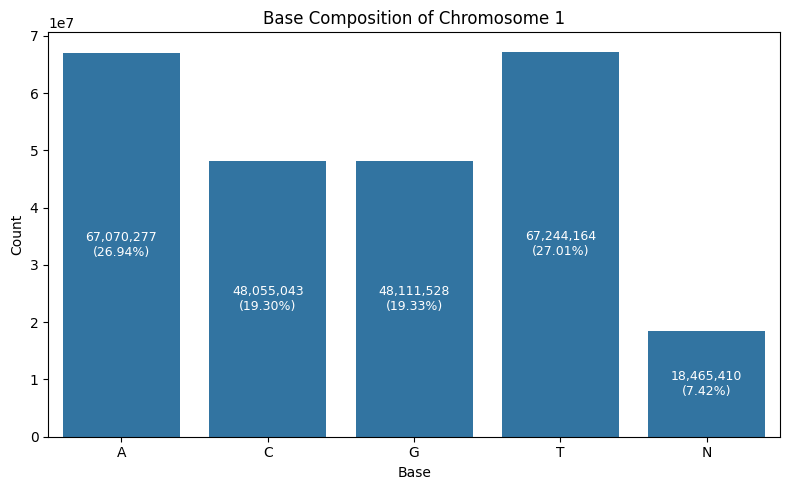

In [6]:
bases = ["A", "C", "G", "T", "N"]
counts = [usable_base_counts.get(base, 0) for base in bases]

total = sum(counts)
percentages = [(c / total) * 100 for c in counts]

# Create DataFrame
df = pd.DataFrame({
    "Base": bases,
    "Count": counts,
    "Percentage": percentages
})

plt.figure(figsize=(8, 5))

# Seaborn barplot
ax = sns.barplot(data=df, x="Base", y="Count")

plt.title("Base Composition of Chromosome 1")
plt.xlabel("Base")
plt.ylabel("Count")

# Add labels inside bars
for i, row in df.iterrows():
    ax.text(
        i,
        row["Count"] * 0.5,
        f"{int(row['Count']):,}\n({row['Percentage']:.2f}%)",
        ha="center",
        va="center",
        color="white",
        fontsize=9
    )

plt.tight_layout()
plt.show()

### GC Content Analysis

GC content refers to the proportion of guanine (G) and cytosine (C) bases in a DNA sequence. It is an important genomic characteristic that influences DNA stability, gene regulation, and sequencing properties.

In this section, we compute the GC content of the usable chromosome 1 sequence to assess whether it aligns with known properties of the human genome.

In [14]:
gc = usable_base_counts["G"] + usable_base_counts["C"]
gc_pct = (gc / len(usable_sequence)) * 100

print(f"GC content: {gc_pct:.2f}%")

GC content: 38.63%


#### Interpretation

The computed GC content of approximately 38.6% is consistent with known characteristics of the human genome, which typically exhibits a GC content in the range of 38–41%. 

This confirms that the extracted chromosome 1 sequence is biologically representative and suitable for downstream analysis and modeling.

### Base Composition along Genome

In [17]:
def sliding_gc(sequence, window=50_000, step=5_000):
    gc_values = []
    positions = []

    for i in range(0, len(sequence) - window, step):
        segment = sequence[i:i+window]
        gc = segment.count("G") + segment.count("C")
        gc_pct = gc / window * 100

        gc_values.append(gc_pct)
        positions.append(i)

    return positions, gc_values

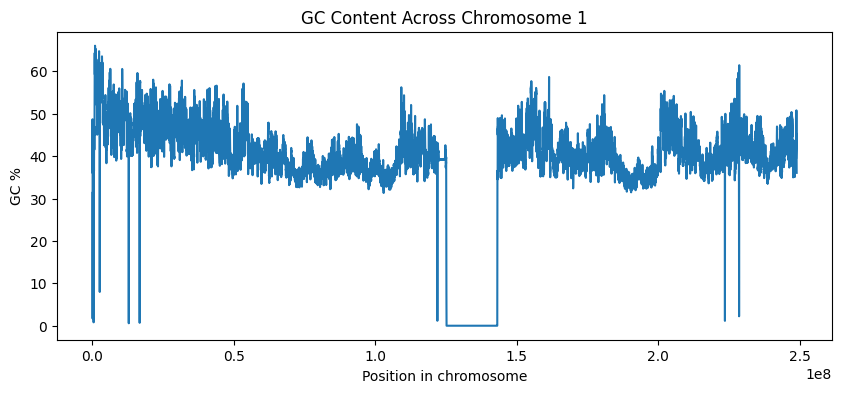

In [18]:
positions, gc_values = sliding_gc(usable_sequence)

plt.figure(figsize=(10, 4))
plt.plot(positions, gc_values)
plt.xlabel("Position in chromosome")
plt.ylabel("GC %")
plt.title("GC Content Across Chromosome 1")
plt.show()

A prominent region with near-zero GC content is observed, corresponding to a large contiguous segment dominated by ambiguous bases (N). This indicates an unresolved or low-confidence region in the reference genome rather than a true biological signal.

### Sequence heatmap (small region)

In [10]:
sample = usable_sequence[:1000]

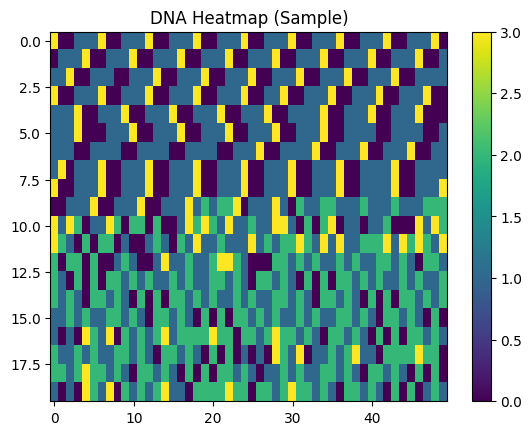

In [11]:
mapping = {"A":0, "C":1, "G":2, "T":3}

import numpy as np
encoded = np.array([mapping.get(b, -1) for b in sample]).reshape(20, 50)

plt.imshow(encoded, aspect="auto")
plt.colorbar()
plt.title("DNA Heatmap (Sample)")
plt.show()

### K-mer Frequency Analysis

K-mers represent short contiguous nucleotide patterns within DNA sequences.  
Analyzing their frequency provides insight into local sequence structure and compositional biases.

Here, we visualize the most frequent k-mers in the usable chromosome 1 sequence.

In [20]:
def count_kmers(sequence, k=2, valid_bases={"A", "C", "G", "T"}):
    kmers = []
    
    for i in range(len(sequence) - k + 1):
        kmer = sequence[i:i+k]
        if set(kmer).issubset(valid_bases):
            kmers.append(kmer)
    
    return Counter(kmers)

In [26]:
k = 2
kmer_counts = count_kmers(usable_sequence, k=k)

total_kmers = sum(kmer_counts.values())

print(f"Number of unique {k}-mers: {len(kmer_counts)}")
print("Most common k-mers:")

for kmer, count in kmer_counts.most_common(10):
    pct = (count / total_kmers) * 100
    print(f"{kmer}: {count:,} ({pct:.2f}%)")

print(f"Total {k}-mers counted: {total_kmers:,}")

Number of unique 2-mers: 16
Most common k-mers:
TT: 22,048,241 (9.57%)
AA: 21,901,540 (9.50%)
AT: 17,121,783 (7.43%)
TG: 16,796,378 (7.29%)
CA: 16,768,284 (7.28%)
AG: 16,448,644 (7.14%)
CT: 16,444,797 (7.13%)
TA: 14,554,789 (6.31%)
GA: 13,845,615 (6.01%)
TC: 13,844,699 (6.01%)
Total 2-mers counted: 230,480,845


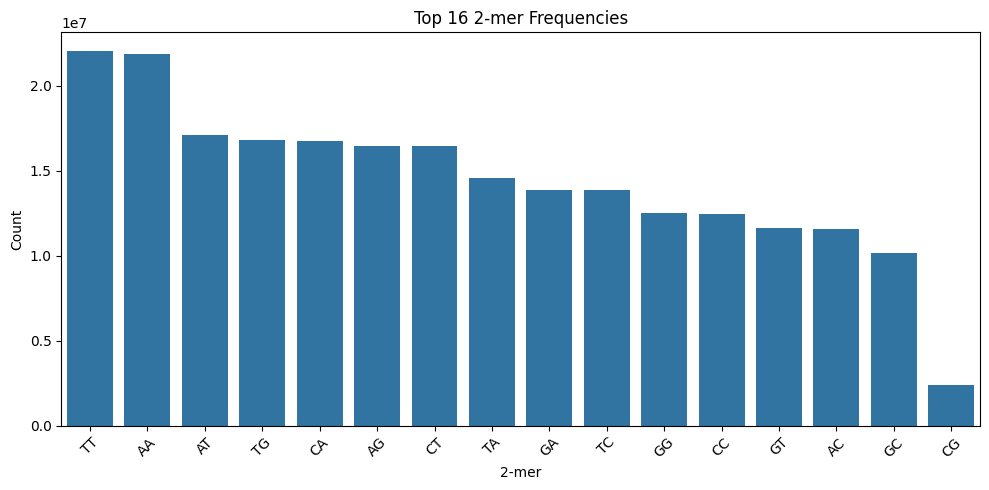

In [34]:
# Convert to DataFrame
df_kmer = pd.DataFrame(
    kmer_counts.items(),
    columns=["kmer", "Count"]
).sort_values("Count", ascending=False)

# Compute percentages
total = df_kmer["Count"].sum()
df_kmer["Percentage"] = df_kmer["Count"] / total * 100

# Optional: limit to top 20 for readability
df_kmer = df_kmer.head(20)

plt.figure(figsize=(10, 5))

ax = sns.barplot(data=df_kmer, x="kmer", y="Count")

plt.title(f"Top {len(df_kmer)} {k}-mer Frequencies")
plt.xlabel(f"{k}-mer")
plt.ylabel("Count")

# Add labels inside bars
# for i, row in df_kmer.iterrows():
#     height = row["Count"]
    
#     ax.text( 
#         i, row["Count"] * 0.2,
#         f"{int(row['Count']):,}\n({row['Percentage']:.2f}%)",
#         ha="center",
#         va="center",
#         color="black",
#         fontsize=8
#     )

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### N Distribution

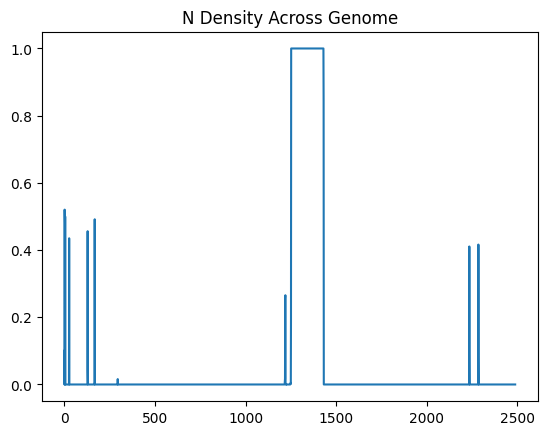

In [12]:
window = 100_000
n_density = []

for i in range(0, len(sequence) - window, window):
    segment = sequence[i:i+window]
    n_density.append(segment.count("N") / window)

plt.plot(n_density)
plt.title("N Density Across Genome")
plt.show()